# Word Embedding: Skip-gram Manual dengan Jaringan Saraf Tiruan

Notebook ini membangun representasi vektor kata (*word embedding*) menggunakan arsitektur **Skip-gram**, dilatih dari nol menggunakan jaringan saraf tiruan sederhana (murni `numpy`, tanpa library embedding siap pakai), sesuai arahan: arsitektur harus terlihat eksplisit - matriks bobot Input->Hidden berukuran `V x 3` dan Hidden->Output berukuran `3 x V` (dimensi embedding = 3).

**Alur:**

```
3 kalimat dari dataset
        |
   Tokenisasi & bangun vocabulary (ukuran V)
        |
   Bangun pasangan (target, context) - Skip-gram
        |
   One-Hot Encoding -> X[i] (target) & y (context)
        |
   Jaringan Saraf: Input (V) -> Hidden/Embedding (3) -> Output (V, softmax)
        |
   Training (forward pass, hitung loss, backpropagation)
        |
   Ambil bobot Hidden Layer (W1, ukuran V x 3) = Vektor Kata
```

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

np.random.seed(42)

## 1. Ambil 3 Kalimat dari Dataset

In [2]:
df = pd.read_excel("../data/dataset_berita_200.xlsx")

def pecah_kalimat(teks):
    return [k.strip() for k in re.split(r"(?<=[.!?])\s+", teks) if len(k.strip().split()) >= 5]

sumber = [(1, "sport"), (50, "sport"), (101, "finance")]

kalimat_terpilih = []
for doc_id, label in sumber:
    teks_artikel = df[df["id"] == doc_id]["isi_berita"].iloc[0]
    kalimat_pertama = pecah_kalimat(teks_artikel)[0]
    kalimat_terpilih.append({"id": doc_id, "label": label, "kalimat": kalimat_pertama})

for k in kalimat_terpilih:
    print("[id={}, {}] {}".format(k["id"], k["label"], k["kalimat"]))

[id=1, sport] Chef de Mission (CdM) Indonesia Todotua Pasaribu terus memonitoring kondisi di Nagoya, Jepang jelang Asian Games 2026.
[id=50, sport] Banyak orang urung coba yoga karena mikir harus lentur dulu atau paham semua gerakan sejak awal.
[id=101, finance] PT NexAl Digital Infrastruktur Tbk (MGLV) yang sebelumnya bernama PT Panca Anugrah Wisesa Tbk, resmi mengubah fokus bisnis usaha.


### Pembersihan Ringan & Tokenisasi

In [3]:
def bersihkan_ringan(teks):
    teks = teks.lower()
    teks = re.sub(r"[^a-z\s]", " ", teks)
    teks = re.sub(r"\s+", " ", teks).strip()
    return teks

daftar_kalimat_token = [bersihkan_ringan(k["kalimat"]).split() for k in kalimat_terpilih]
for tokens in daftar_kalimat_token:
    print(tokens)

['chef', 'de', 'mission', 'cdm', 'indonesia', 'todotua', 'pasaribu', 'terus', 'memonitoring', 'kondisi', 'di', 'nagoya', 'jepang', 'jelang', 'asian', 'games']
['banyak', 'orang', 'urung', 'coba', 'yoga', 'karena', 'mikir', 'harus', 'lentur', 'dulu', 'atau', 'paham', 'semua', 'gerakan', 'sejak', 'awal']
['pt', 'nexal', 'digital', 'infrastruktur', 'tbk', 'mglv', 'yang', 'sebelumnya', 'bernama', 'pt', 'panca', 'anugrah', 'wisesa', 'tbk', 'resmi', 'mengubah', 'fokus', 'bisnis', 'usaha']


## 2. Bangun Vocabulary

In [4]:
semua_token = [kata for kalimat in daftar_kalimat_token for kata in kalimat]
vocab = sorted(set(semua_token))
word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = {i: w for w, i in word2idx.items()}
V = len(vocab)

print(f"Ukuran vocabulary (V): {V}")
print(vocab)

Ukuran vocabulary (V): 49
['anugrah', 'asian', 'atau', 'awal', 'banyak', 'bernama', 'bisnis', 'cdm', 'chef', 'coba', 'de', 'di', 'digital', 'dulu', 'fokus', 'games', 'gerakan', 'harus', 'indonesia', 'infrastruktur', 'jelang', 'jepang', 'karena', 'kondisi', 'lentur', 'memonitoring', 'mengubah', 'mglv', 'mikir', 'mission', 'nagoya', 'nexal', 'orang', 'paham', 'panca', 'pasaribu', 'pt', 'resmi', 'sebelumnya', 'sejak', 'semua', 'tbk', 'terus', 'todotua', 'urung', 'usaha', 'wisesa', 'yang', 'yoga']


## 3. Bangun Pasangan (Target, Context) - Skip-gram

Untuk setiap kata (*target*), kata-kata di sekitarnya dalam jendela `window` menjadi *context*-nya. Pasangan dibuat per kalimat (tidak menyeberang antar kalimat).

In [5]:
def buat_pasangan_skipgram(tokens, window=2):
    pasangan = []
    for i, target in enumerate(tokens):
        mulai = max(0, i - window)
        akhir = min(len(tokens), i + window + 1)
        for j in range(mulai, akhir):
            if j != i:
                pasangan.append((target, tokens[j]))
    return pasangan

WINDOW = 2
semua_pasangan = []
for tokens in daftar_kalimat_token:
    semua_pasangan += buat_pasangan_skipgram(tokens, window=WINDOW)

print(f"Total pasangan (target, context): {len(semua_pasangan)}")
for t, c in semua_pasangan[:10]:
    print(f"  target='{t:12}' -> context='{c}'")

Total pasangan (target, context): 186
  target='chef        ' -> context='de'
  target='chef        ' -> context='mission'
  target='de          ' -> context='chef'
  target='de          ' -> context='mission'
  target='de          ' -> context='cdm'
  target='mission     ' -> context='chef'
  target='mission     ' -> context='de'
  target='mission     ' -> context='cdm'
  target='mission     ' -> context='indonesia'
  target='cdm         ' -> context='de'


## 4. One-Hot Encoding: X (Target) dan y (Context)

- **X[i]**: one-hot vector dari kata *target* pada pasangan ke-i (ukuran V)
- **y[i]**: one-hot vector dari kata *context* pada pasangan ke-i (ukuran V)

In [6]:
def one_hot(idx, size):
    vektor = np.zeros(size)
    vektor[idx] = 1
    return vektor

X = np.array([one_hot(word2idx[t], V) for t, c in semua_pasangan])
y = np.array([one_hot(word2idx[c], V) for t, c in semua_pasangan])

print("Bentuk X (target) :", X.shape, "-> (jumlah pasangan, V)")
print("Bentuk y (context):", y.shape)

Bentuk X (target) : (186, 49) -> (jumlah pasangan, V)
Bentuk y (context): (186, 49)


In [7]:
i = 0
target_i, context_i = semua_pasangan[i]
print(f"Contoh pasangan ke-{i}: target='{target_i}', context='{context_i}'\n")
print(f"X[{i}] (one-hot target, panjang {V}):")
print(X[i].astype(int))
print(f"\ny[{i}] (one-hot context, panjang {V}):")
print(y[i].astype(int))

Contoh pasangan ke-0: target='chef', context='de'

X[0] (one-hot target, panjang 49):
[0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0]

y[0] (one-hot context, panjang 49):
[0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0]


## 5. Arsitektur Jaringan Saraf Tiruan

```
Input (V)  --[W1: V x 3]-->  Hidden/Embedding (3)  --[W2: 3 x V]-->  Output (V)  --[softmax]-->  Probabilitas
```

- **W1** berukuran `V x 3`: setiap baris menjadi vektor embedding (3 dimensi) untuk kata yang bersangkutan setelah training.
- **W2** berukuran `3 x V`: memetakan kembali dari ruang embedding ke ruang vocabulary untuk memprediksi kata context.

In [8]:
DIM_EMBEDDING = 3  # sesuai spesifikasi: hidden layer berdimensi 3

W1 = np.random.randn(V, DIM_EMBEDDING) * 0.1   # Input -> Hidden,  ukuran V x 3
W2 = np.random.randn(DIM_EMBEDDING, V) * 0.1   # Hidden -> Output, ukuran 3 x V

print("Ukuran W1 (Input -> Hidden) :", W1.shape)
print("Ukuran W2 (Hidden -> Output):", W2.shape)

Ukuran W1 (Input -> Hidden) : (49, 3)
Ukuran W2 (Hidden -> Output): (3, 49)


In [9]:
def softmax(x):
    x_geser = x - np.max(x, axis=1, keepdims=True)
    e = np.exp(x_geser)
    return e / np.sum(e, axis=1, keepdims=True)

def forward_pass(X, W1, W2):
    h = X @ W1          # (N, 3)  - proyeksi ke ruang embedding
    u = h @ W2          # (N, V)  - skor mentah tiap kata di vocabulary
    y_pred = softmax(u) # (N, V)  - probabilitas tiap kata sebagai context
    return h, u, y_pred

### Uji Forward Pass Sebelum Training (Bobot Masih Acak)

In [10]:
h_awal, u_awal, y_pred_awal = forward_pass(X[:1], W1, W2)
print("Prediksi probabilitas sebelum training (untuk X[0]):")
print(np.round(y_pred_awal[0], 3))
print(f"Prediksi tertinggi: '{idx2word[np.argmax(y_pred_awal[0])]}' (masih acak/belum bermakna)")

Prediksi probabilitas sebelum training (untuk X[0]):
[0.021 0.02  0.021 0.02  0.02  0.021 0.02  0.02  0.02  0.021 0.02  0.02
 0.021 0.02  0.02  0.021 0.021 0.021 0.021 0.02  0.02  0.02  0.021 0.021
 0.021 0.02  0.021 0.02  0.02  0.021 0.02  0.02  0.02  0.02  0.021 0.021
 0.02  0.02  0.021 0.02  0.021 0.021 0.02  0.02  0.02  0.02  0.021 0.021
 0.02 ]
Prediksi tertinggi: 'harus' (masih acak/belum bermakna)


## 6. Training: Forward Pass, Hitung Loss, Backpropagation

In [19]:
from tqdm import tqdm

def hitung_loss(y_pred, y_target):
    return -np.sum(y_target * np.log(y_pred + 1e-9)) / len(y_target)

LEARNING_RATE = 0.5   # dari 0.05, dinaikkan 10x
EPOCHS = 5000          # dari 1000, dinaikkan 5x
riwayat_loss = []

progress = tqdm(range(EPOCHS), desc="Training Skip-gram")
for epoch in progress:
    h, u, y_pred = forward_pass(X, W1, W2)
    loss = hitung_loss(y_pred, y)
    riwayat_loss.append(loss)

    dU = (y_pred - y) / len(X)      # (N, V)
    dW2 = h.T @ dU                  # (3, V)
    dH = dU @ W2.T                  # (N, 3)
    dW1 = X.T @ dH                  # (V, 3)

    W1 -= LEARNING_RATE * dW1
    W2 -= LEARNING_RATE * dW2

    if epoch % 20 == 0 or epoch == EPOCHS - 1:
        progress.set_postfix({"loss": f"{loss:.4f}"})

penurunan = (riwayat_loss[0] - riwayat_loss[-1]) / riwayat_loss[0] * 100
print(f"Loss awal  : {riwayat_loss[0]:.4f}")
print(f"Loss akhir : {riwayat_loss[-1]:.4f}")
print(f"Penurunan  : {penurunan:.1f}%")

Training Skip-gram: 100%|██████████| 5000/5000 [00:03<00:00, 1429.05it/s, loss=1.7131]

Loss awal  : 3.8702
Loss akhir : 1.7131
Penurunan  : 55.7%


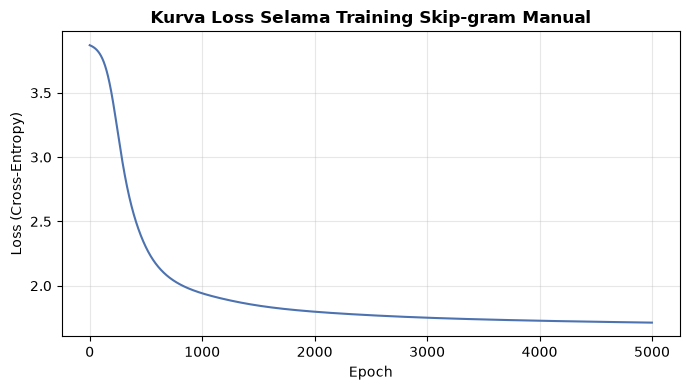

In [20]:
plt.figure(figsize=(7, 4))
plt.plot(riwayat_loss, color="#4C72B0")
plt.xlabel("Epoch")
plt.ylabel("Loss (Cross-Entropy)")
plt.title("Kurva Loss Selama Training Skip-gram Manual", fontsize=12, fontweight="bold")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Bandingkan Prediksi Sebelum vs Sesudah Training

In [22]:
_, _, y_pred_akhir = forward_pass(X[:1], W1, W2)
print(f"Pasangan uji: target='{target_i}', context asli='{context_i}'\n")

print("SEBELUM training - top 3 prediksi:")
for idx in np.argsort(y_pred_awal[0])[::-1][:3]:
    print(f"  {idx2word[idx]:12} (probabilitas: {y_pred_awal[0][idx]:.3f})")

print("\nSESUDAH training - top 3 prediksi:")
for idx in np.argsort(y_pred_akhir[0])[::-1][:3]:
    print(f"  {idx2word[idx]:12} (probabilitas: {y_pred_akhir[0][idx]:.3f})")

Pasangan uji: target='chef', context asli='de'

SEBELUM training - top 3 prediksi:
  harus        (probabilitas: 0.021)
  semua        (probabilitas: 0.021)
  karena       (probabilitas: 0.021)

SESUDAH training - top 3 prediksi:
  de           (probabilitas: 0.518)
  mission      (probabilitas: 0.421)
  chef         (probabilitas: 0.032)


## 7. Hasil Akhir: Vektor Kata (W1, ukuran V x 3)

In [23]:
embedding_df = pd.DataFrame(W1, index=vocab, columns=["dim_1", "dim_2", "dim_3"])
embedding_df.style.background_gradient(cmap="RdBu", axis=None).format("{:.3f}")

,dim_1,dim_2,dim_3
anugrah,-2.237,-5.120,1.533
asian,0.911,3.721,2.895
atau,1.652,3.096,-0.551
awal,4.630,1.005,0.603
banyak,1.771,-3.315,-3.122
bernama,-2.564,-2.948,-1.728
bisnis,0.505,-2.832,4.129
cdm,-3.460,1.792,-1.744
chef,-2.330,2.672,-2.925
coba,1.098,-1.756,-4.079


### Kata Paling Mirip (Cosine Similarity)

In [24]:
def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-9)

def kata_paling_mirip(kata, top_n=5):
    vektor_kata = W1[word2idx[kata]]
    similarity = {w: cosine_similarity(vektor_kata, W1[word2idx[w]]) for w in vocab if w != kata}
    return sorted(similarity.items(), key=lambda x: -x[1])[:top_n]

kata_uji = vocab[0]
print(f"Kata paling mirip dengan '{kata_uji}':")
for w, skor in kata_paling_mirip(kata_uji):
    print(f"  {w:12} (cosine similarity: {skor:.3f})")

Kata paling mirip dengan 'anugrah':
  wisesa       (cosine similarity: 0.993)
  tbk          (cosine similarity: 0.992)
  resmi        (cosine similarity: 0.919)
  nexal        (cosine similarity: 0.858)
  digital      (cosine similarity: 0.837)


### Visualisasi Embedding (3 Dimensi -> Diproyeksikan ke 2D dengan PCA)

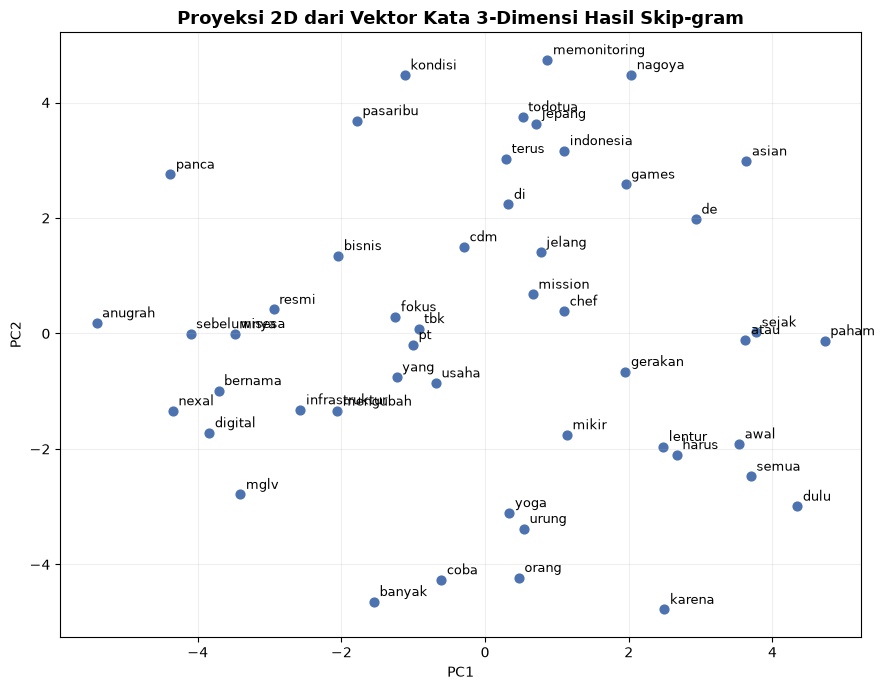

In [25]:
from sklearn.decomposition import PCA

pca_kata = PCA(n_components=2, random_state=42)
embedding_2d = pca_kata.fit_transform(W1)

plt.figure(figsize=(9, 7))
plt.scatter(embedding_2d[:, 0], embedding_2d[:, 1], color="#4C72B0", s=40)
for i, kata in enumerate(vocab):
    plt.annotate(kata, (embedding_2d[i, 0], embedding_2d[i, 1]), fontsize=9,
                 xytext=(4, 4), textcoords="offset points")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Proyeksi 2D dari Vektor Kata 3-Dimensi Hasil Skip-gram", fontsize=13, fontweight="bold")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Ringkasan

- Arsitektur Skip-gram manual: Input (V) -> Hidden/Embedding (3) -> Output (V), dilatih dengan backpropagation dan cross-entropy loss dari nol menggunakan `numpy`.
- `X[i]` (one-hot target) dan `y[i]` (one-hot context) dibentuk eksplisit dari pasangan Skip-gram sebelum diberikan ke jaringan.
- Bobot **W1** (ukuran `V x 3`) menjadi vektor embedding akhir tiap kata.
- Korpus yang dipakai sangat kecil (3 kalimat), sehingga hasil kemiripan antar kata bersifat ilustratif untuk memahami mekanisme Skip-gram, bukan embedding siap pakai secara praktis.